# Analyse — GridWorld (5×5)

GridWorld est un environnement mono-joueur sur une grille 5×5 avec un mur, une case piège et une case but. L'agent reçoit +1 en atteignant le but et -1 dans le piège. La policy optimale boucle sur ~ 8 steps.

**Reward attendu :** 1.0 (atteint la case but) ou -1.0 (case piège), distance Manhattan minimale = 8 steps.

**Sources de données :**

| Fichier | Mode | Description |
|---|---|---|
| `results/grid_world/{agent}/{run}/training_curve.csv` | TRAINING | reward par épisode pendant l'entraînement |
| `results/grid_world/{agent}/{run}/metrics_reeval.csv` | INFERENCE | politique gelée, ε=0, balance P0/P1 si adversarial |
| `results/grid_world/{agent}/{run}/metrics.csv` | INFERENCE (fallback) | éval pendant l'entraînement quand reeval absent |
| `results/grid_world/{mcts,random_rollout}/budget_sweep_seed42/metrics.csv` | INFERENCE | sweep budget→score (planning) |

**Plan :**
1. Inventaire des runs
2. [TRAINING] Courbes d'apprentissage
3. [INFERENCE] Reward moyen au meilleur checkpoint
4. [INFERENCE] Reward par checkpoint (évolution)
5. [INFERENCE] Évolution du reward par checkpoint
6. [INFERENCE] Longueur d'épisode
7. [INFERENCE] Termination vs Truncation
8. [INFERENCE] Temps d'inférence par coup
9. [INFERENCE] Reward aux checkpoints du syllabus (1k / 10k / 100k / 1M)
10. [INFERENCE] Best vs last checkpoint
11. [INFERENCE] Termination vs truncation
12. [PLANNING] MCTS et RandomRollout — sweep budget
13. [PARETO] Reward × latence (toutes méthodes)
14. Hyperparamètres
15. Synthèse — ranking final
16. Observations critiques


## 0. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
sys.path.insert(0, str(Path.cwd().parent / "notebooks"))
from _report_utils import (
    LEARNING_AGENTS, PLANNING_AGENTS, ALL_AGENTS, ADVERSARIAL_ENVS,
    discover_runs, load_eval_metrics, load_training_curve, load_planning_metrics,
    project_root, results_dir, agent_color, setup_plot_style,
)

setup_plot_style()
ENV_NAME  = "grid_world"
ENV_TITLE = "GridWorld (5×5)"
EXPECTED_CHECKPOINTS = [1000, 10000, 100000, 1000000]
IS_ADVERSARIAL = ENV_NAME in ADVERSARIAL_ENVS

print("Env :", ENV_NAME, "(", "adversarial" if IS_ADVERSARIAL else "solo", ")")
print("Project root :", project_root())


Env : grid_world ( solo )
Project root : /Users/brandontchakaniyungeko/ESGI-dev/5IABD/T2/deep_reinforcement_learning/projet


In [2]:
learning_runs, planning_runs = discover_runs(ENV_NAME)
print(f"Learning runs : {len(learning_runs)}")
print(f"Planning runs : {len(planning_runs)}")

eval_frames = [load_eval_metrics(r) for r in learning_runs]
df_eval = pd.concat([f for f in eval_frames if not f.empty], ignore_index=True) if eval_frames else pd.DataFrame()

train_frames = [load_training_curve(r) for r in learning_runs]
df_train = pd.concat([f for f in train_frames if not f.empty], ignore_index=True) if train_frames else pd.DataFrame()

planning_frames = [load_planning_metrics(r) for r in planning_runs]
df_planning = pd.concat([f for f in planning_frames if not f.empty], ignore_index=True) if planning_frames else pd.DataFrame()

print(f"\nEval rows     : {len(df_eval)}")
print(f"Training rows : {len(df_train)}")
print(f"Planning rows : {len(df_planning)}")


Learning runs : 24
Planning runs : 2

Eval rows     : 96
Training rows : 1233512
Planning rows : 12


In [3]:
def best_per_agent_eval(df: pd.DataFrame, by: str = "mean_reward") -> pd.DataFrame:
    """For each agent, return the row with the highest score (`by`).
    Tie-break on lower mean_steps."""
    if df.empty or by not in df.columns:
        return df.iloc[0:0]
    sub = df.dropna(subset=[by]).sort_values([by, "mean_steps"], ascending=[False, True])
    return sub.groupby("agent", as_index=False).head(1)

def best_per_agent_planning(df: pd.DataFrame, by: str = "mean_reward") -> pd.DataFrame:
    """Best-budget row per planning agent."""
    if df.empty or by not in df.columns:
        return df.iloc[0:0]
    sub = df.dropna(subset=[by]).sort_values([by, "budget"], ascending=[False, True])
    return sub.groupby("agent", as_index=False).head(1)


## 1. Inventaire des runs

In [4]:
rows = []
for r in learning_runs:
    cfg = r["config"]
    rows.append({
        "type": "learning",
        "agent": r["agent"],
        "seed": r["seed"],
        "n_checkpoints": sum(1 for _ in r["run_dir"].glob("model_*.pt")),
        "num_episodes": cfg.get("training", {}).get("num_episodes", "-"),
        "run_name": r["run_name"][:75] + ("…" if len(r["run_name"]) > 75 else ""),
    })
for r in planning_runs:
    cfg = r["config"]
    rows.append({
        "type": "planning",
        "agent": r["agent"],
        "seed": r["seed"],
        "n_checkpoints": "-",
        "num_episodes": "-",
        "run_name": r["run_name"][:75],
    })

inv = pd.DataFrame(rows)
print(f"{len(inv)} runs au total")
inv


26 runs au total


,type,agent,seed,n_checkpoints,num_episodes,run_name
0,learning,ddqn,123,4,100000,batch_size64_buffer_capacity10000_epsilon_deca...
1,learning,ddqn,42,4,100000,batch_size64_buffer_capacity10000_epsilon_deca...
2,learning,ddqn,42,3,50000,batch_size64_buffer_capacity10000_epsilon_deca...
3,learning,ddqn_er,123,4,100000,batch_size64_buffer_capacity10000_epsilon_deca...
4,learning,ddqn_er,42,4,100000,batch_size64_buffer_capacity10000_epsilon_deca...
5,learning,ddqn_er,42,3,50000,batch_size64_buffer_capacity10000_epsilon_deca...
6,learning,ddqn_per,123,4,100000,batch_size64_buffer_capacity10000_epsilon_deca...
7,learning,ddqn_per,42,4,100000,batch_size64_buffer_capacity10000_epsilon_deca...
8,learning,ddqn_per,42,3,50000,batch_size64_buffer_capacity10000_epsilon_deca...
9,learning,dqn,123,4,100000,batch_size64_buffer_capacity10000_epsilon_deca...


## 2. [TRAINING] Courbes d'apprentissage

Reward par épisode pendant l'entraînement (mode stochastique : ε-greedy pour Q-learning, sampling pour policy-gradient). Moyenne glissante sur 200 épisodes pour lisser le bruit. Une seed représentative par agent (seed 42 si disponible). Random est plat (pas d'apprentissage).

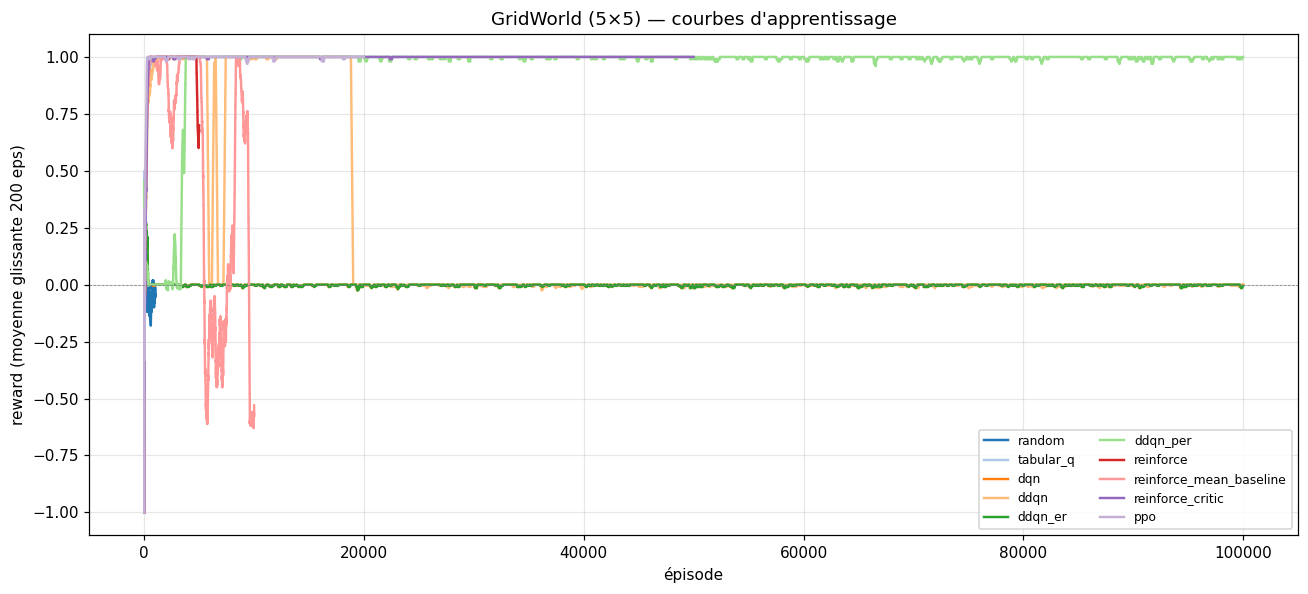

In [5]:
WINDOW = 200

if df_train.empty:
    print("Pas de courbes d'apprentissage.")
else:
    fig, ax = plt.subplots(figsize=(12, 5.5))
    for agent in [a for a in LEARNING_AGENTS if a in df_train["agent"].unique()]:
        sub = df_train[df_train["agent"] == agent]
        seeds_sorted = sorted(sub["seed"].unique(), key=lambda s: (s != 42, s))
        chosen = sub[sub["seed"] == seeds_sorted[0]]
        if chosen["run_name"].nunique() > 1:
            best_run = chosen.groupby("run_name").size().idxmax()
            chosen = chosen[chosen["run_name"] == best_run]
        chosen = chosen.sort_values("episode")
        if chosen.empty:
            continue
        smoothed = chosen["reward"].rolling(WINDOW, min_periods=1).mean()
        ax.plot(chosen["episode"], smoothed, label=agent, color=agent_color(agent), linewidth=1.6)
    ax.set_xlabel("épisode")
    ax.set_ylabel(f"reward (moyenne glissante {WINDOW} eps)")
    ax.set_title(f"{ENV_TITLE} — courbes d'apprentissage")
    ax.axhline(0, color="gray", lw=0.5, ls="--")
    ax.legend(loc="best", fontsize=8, ncol=2, framealpha=0.85)
    plt.tight_layout()
    plt.show()


## 3. [INFERENCE] Reward moyen au meilleur checkpoint

Pour chaque agent apprenant, on prend le checkpoint qui maximise `mean_reward`. Pour MCTS / RandomRollout, on prend le résultat au plus gros budget. **Les planning agents sont inclus dans cette comparaison.**

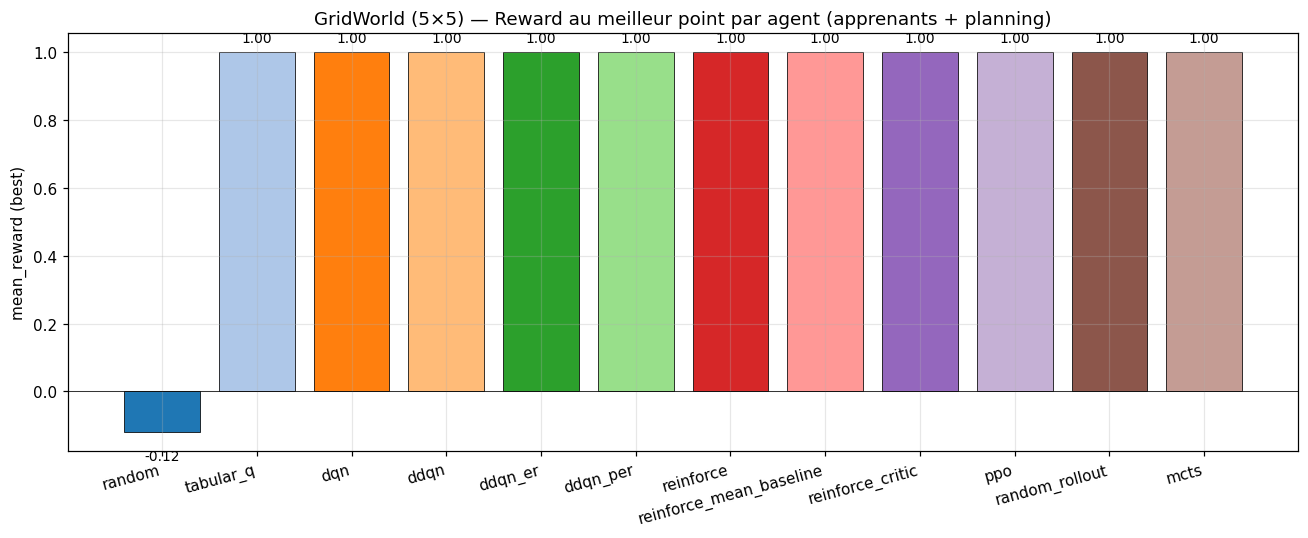

,mean_reward,type
random,-0.1200,learning
tabular_q,1.0000,learning
dqn,1.0000,learning
ddqn,1.0000,learning
ddqn_er,1.0000,learning
ddqn_per,1.0000,learning
reinforce,1.0000,learning
reinforce_mean_baseline,1.0000,learning
reinforce_critic,1.0000,learning
ppo,1.0000,learning


In [6]:
best_learn = best_per_agent_eval(df_eval).set_index("agent")
best_plan = best_per_agent_planning(df_planning).set_index("agent")

all_idx = [a for a in ALL_AGENTS if a in best_learn.index] +           [a for a in PLANNING_AGENTS if a in best_plan.index]
seen = set()
all_idx = [a for a in all_idx if not (a in seen or seen.add(a))]

values = []
for a in all_idx:
    if a in best_learn.index and pd.notna(best_learn.loc[a, "mean_reward"]):
        values.append(best_learn.loc[a, "mean_reward"])
    elif a in best_plan.index:
        values.append(best_plan.loc[a, "mean_reward"])
    else:
        values.append(np.nan)

fig, ax = plt.subplots(figsize=(12, 5))
colors = [agent_color(a) for a in all_idx]
bars = ax.bar(all_idx, values, color=colors, edgecolor="black", linewidth=0.5)
for b, v in zip(bars, values):
    if pd.notna(v):
        ax.text(b.get_x() + b.get_width()/2, v + 0.02 if v >= 0 else v - 0.05,
                f"{v:.2f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("mean_reward (best)")
ax.set_title(f"{ENV_TITLE} — Reward au meilleur point par agent (apprenants + planning)")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

# Tableau récapitulatif
rec = pd.DataFrame({"mean_reward": values, "type": ["planning" if a in PLANNING_AGENTS else "learning" for a in all_idx]}, index=all_idx)
display(rec.round(3))


## 4. [INFERENCE] Évolution du reward par checkpoint

Un point par checkpoint, courbe par agent. Permet de détecter les agents qui régressent en fin d'entraînement.

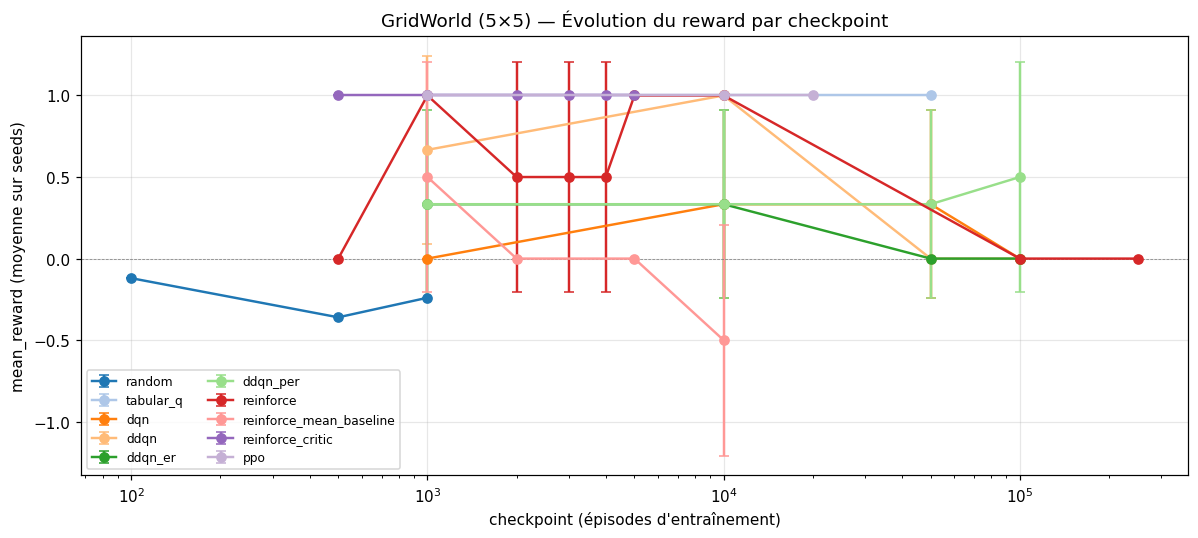

In [7]:
if df_eval.empty:
    print("Pas de données d'évaluation.")
else:
    fig, ax = plt.subplots(figsize=(11, 5))
    for agent in [a for a in LEARNING_AGENTS if a in df_eval["agent"].unique()]:
        sub = df_eval[df_eval["agent"] == agent].dropna(subset=["mean_reward"])
        if sub.empty:
            continue
        agg = sub.groupby("checkpoint", as_index=False).agg(
            mean_reward=("mean_reward", "mean"),
            std=("mean_reward", "std"),
        ).fillna(0)
        ax.errorbar(agg["checkpoint"], agg["mean_reward"], yerr=agg["std"],
                    label=agent, color=agent_color(agent), marker="o",
                    capsize=3, linewidth=1.6)
    ax.set_xscale("log")
    ax.set_xlabel("checkpoint (épisodes d'entraînement)")
    ax.set_ylabel("mean_reward (moyenne sur seeds)")
    ax.set_title(f"{ENV_TITLE} — Évolution du reward par checkpoint")
    ax.axhline(0, color="gray", lw=0.5, ls="--")
    ax.legend(loc="best", fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()


## 7. [INFERENCE] Longueur d'épisode (steps)

Combien de steps prend une partie en moyenne. Une longueur proche de `max_steps=10000` indique une **truncation** (politique bloquée). Les planning agents sont inclus à leur meilleur budget.

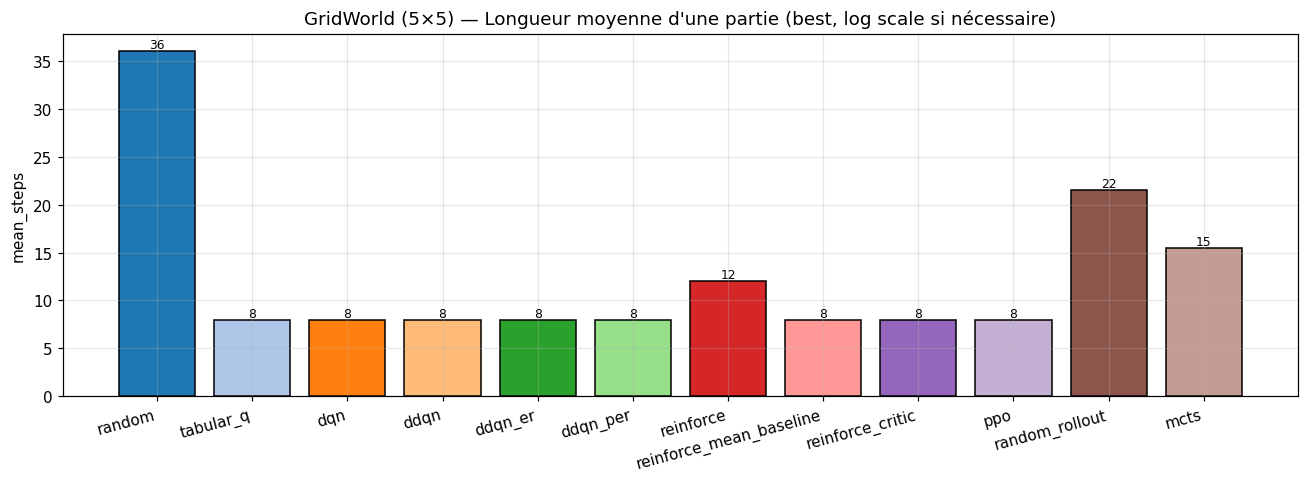

,mean_steps,type
agent,,
random,36.0000,learning
tabular_q,8.0000,learning
dqn,8.0000,learning
ddqn,8.0000,learning
ddqn_er,8.0000,learning
ddqn_per,8.0000,learning
reinforce,12.0000,learning
reinforce_mean_baseline,8.0000,learning
reinforce_critic,8.0000,learning


In [8]:
rows = []
for a in LEARNING_AGENTS:
    if a not in df_eval["agent"].unique():
        continue
    sub = df_eval[df_eval["agent"] == a].dropna(subset=["mean_reward", "mean_steps"])
    if sub.empty:
        continue
    best = sub.sort_values("mean_reward", ascending=False).iloc[0]
    rows.append({"agent": a, "mean_steps": best["mean_steps"], "type": "learning"})

for a in PLANNING_AGENTS:
    if df_planning.empty or a not in df_planning["agent"].unique():
        continue
    sub = df_planning[df_planning["agent"] == a].dropna(subset=["mean_reward", "mean_steps"])
    if sub.empty:
        continue
    best = sub.sort_values("mean_reward", ascending=False).iloc[0]
    rows.append({"agent": a, "mean_steps": best["mean_steps"], "type": "planning"})

if not rows:
    print("Pas de données mean_steps.")
else:
    df_steps = pd.DataFrame(rows).set_index("agent")
    df_steps = df_steps.reindex([a for a in ALL_AGENTS if a in df_steps.index])
    fig, ax = plt.subplots(figsize=(12, 4.5))
    bars = ax.bar(df_steps.index, df_steps["mean_steps"],
                  color=[agent_color(a) for a in df_steps.index], edgecolor="black")
    for b, v in zip(bars, df_steps["mean_steps"]):
        ax.text(b.get_x() + b.get_width()/2, v, f"{v:.0f}",
                ha="center", va="bottom", fontsize=8)
    ax.set_ylabel("mean_steps")
    ax.set_title(f"{ENV_TITLE} — Longueur moyenne d'une partie (best, log scale si nécessaire)")
    if df_steps["mean_steps"].max() > 1000:
        ax.set_yscale("log")
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.show()
    display(df_steps.round(1))


## 8. [INFERENCE] Temps d'inférence par coup (ms)

Métrique demandée par le syllabus. Mesurée côté CPU dans `agent.act(state)`. Échelle log car les ordres de grandeur varient (`random` ≈ 1 µs, `mcts` budget=1000 ≈ 100 ms).

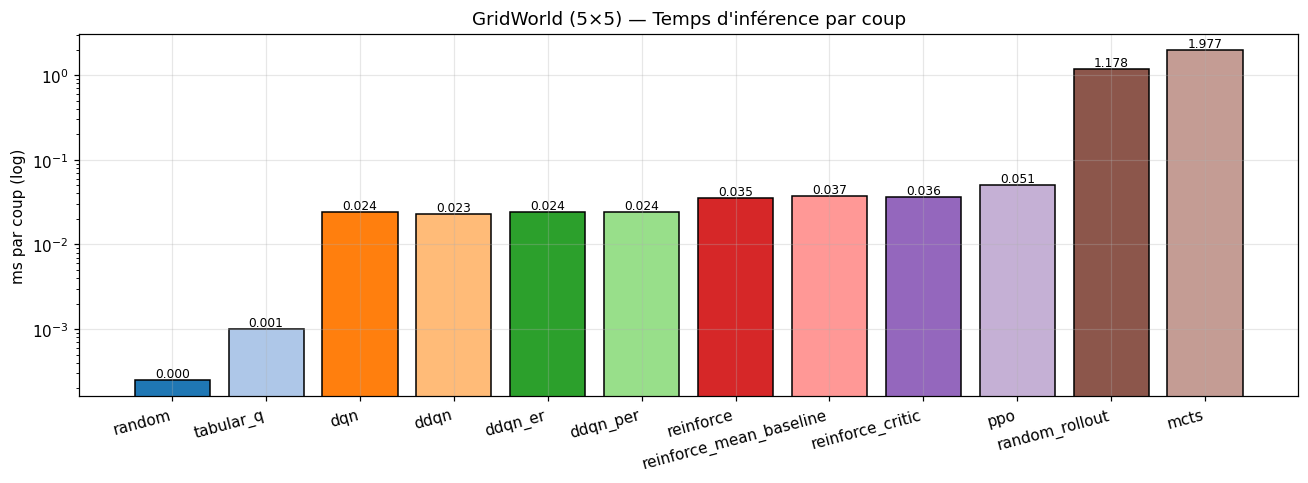

,mean_action_time_ms,type
agent,,
random,0.0003,learning
tabular_q,0.0010,learning
dqn,0.0240,learning
ddqn,0.0230,learning
ddqn_er,0.0240,learning
ddqn_per,0.0240,learning
reinforce,0.0350,learning
reinforce_mean_baseline,0.0370,learning
reinforce_critic,0.0360,learning


In [9]:
rows = []
for a in LEARNING_AGENTS:
    if a not in df_eval["agent"].unique():
        continue
    sub = df_eval[df_eval["agent"] == a].dropna(subset=["mean_reward", "mean_action_time_ms"])
    if sub.empty:
        continue
    best = sub.sort_values("mean_reward", ascending=False).iloc[0]
    rows.append({"agent": a, "mean_action_time_ms": best["mean_action_time_ms"], "type": "learning"})

for a in PLANNING_AGENTS:
    if df_planning.empty or a not in df_planning["agent"].unique():
        continue
    sub = df_planning[df_planning["agent"] == a].dropna(subset=["mean_reward", "mean_action_time_ms"])
    if sub.empty:
        continue
    best = sub.sort_values("mean_reward", ascending=False).iloc[0]
    rows.append({"agent": a, "mean_action_time_ms": best["mean_action_time_ms"], "type": "planning"})

if not rows:
    print("Pas de données temps.")
else:
    df_t = pd.DataFrame(rows).set_index("agent")
    df_t = df_t.reindex([a for a in ALL_AGENTS if a in df_t.index])
    fig, ax = plt.subplots(figsize=(12, 4.5))
    bars = ax.bar(df_t.index, df_t["mean_action_time_ms"],
                  color=[agent_color(a) for a in df_t.index], edgecolor="black")
    for b, v in zip(bars, df_t["mean_action_time_ms"]):
        ax.text(b.get_x() + b.get_width()/2, v, f"{v:.3f}",
                ha="center", va="bottom", fontsize=8)
    ax.set_yscale("log")
    ax.set_ylabel("ms par coup (log)")
    ax.set_title(f"{ENV_TITLE} — Temps d'inférence par coup")
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.show()
    display(df_t.round(4))


## 9. [INFERENCE] Reward aux checkpoints du syllabus

Format direct du syllabus : score moyen de la policy gelée évaluée à 1k, 10k, 100k, 1M parties d'entraînement.

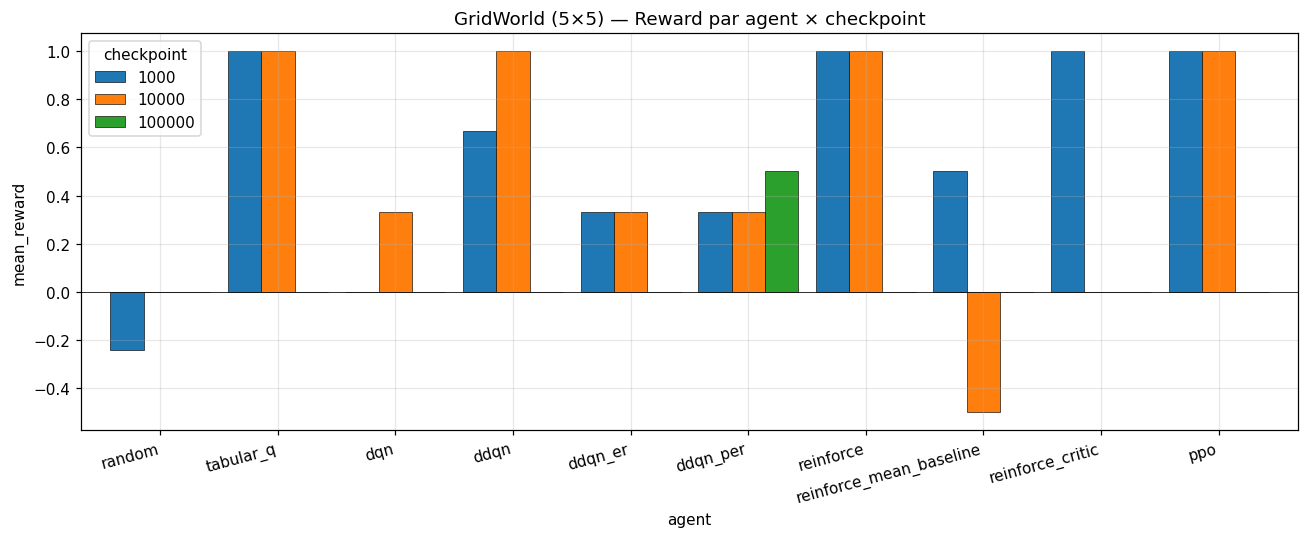

checkpoint,1000,10000,100000
agent,,,
random,-0.2400,NaN,NaN
tabular_q,1.0000,1.0000,NaN
dqn,0.0000,0.3330,0.0000
ddqn,0.6670,1.0000,0.0000
ddqn_er,0.3330,0.3330,0.0000
ddqn_per,0.3330,0.3330,0.5000
reinforce,1.0000,1.0000,0.0000
reinforce_mean_baseline,0.5000,-0.5000,NaN
reinforce_critic,1.0000,NaN,NaN


In [10]:
checkpoints_target = [1000, 10000, 100000, 1000000]
sub = df_eval[df_eval["checkpoint"].isin(checkpoints_target)]
if sub.empty:
    print("Pas de checkpoints dans la liste cible.")
else:
    pivot = sub.pivot_table(index="agent", columns="checkpoint", values="mean_reward", aggfunc="mean")
    pivot = pivot.reindex([a for a in LEARNING_AGENTS if a in pivot.index],
                          columns=[c for c in checkpoints_target if c in pivot.columns])
    fig, ax = plt.subplots(figsize=(12, 5))
    pivot.plot(kind="bar", ax=ax, edgecolor="black", linewidth=0.4, width=0.85)
    ax.axhline(0, color="black", lw=0.5)
    ax.set_ylabel("mean_reward")
    ax.set_title(f"{ENV_TITLE} — Reward par agent × checkpoint")
    plt.xticks(rotation=15, ha="right")
    plt.legend(title="checkpoint")
    plt.tight_layout()
    plt.show()
    display(pivot.round(3))


## 10. [INFERENCE] Best vs last checkpoint — détection de régression

« Plus d'épisodes ≠ meilleur résultat ». Pour chaque agent, on compare le checkpoint qui a la meilleure performance vs le dernier checkpoint sauvegardé. Un écart > 0 signifie que l'agent a régressé en fin d'entraînement.

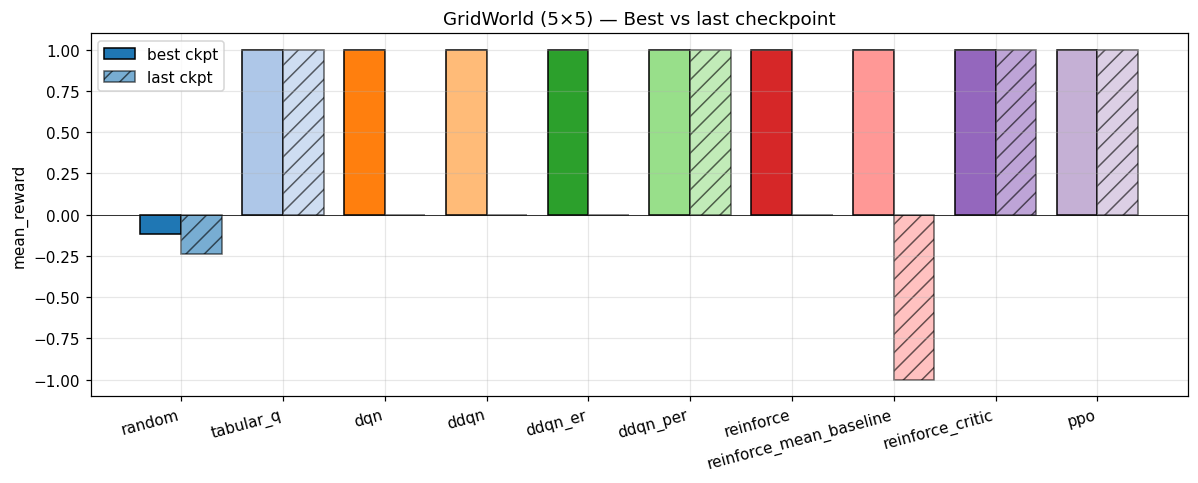

,best_ckpt,best_reward,last_ckpt,last_reward,regression
agent,,,,,
random,100,-0.1200,1000,-0.2400,YES
tabular_q,1000,1.0000,50000,1.0000,no
dqn,10000,1.0000,100000,0.0000,YES
ddqn,10000,1.0000,100000,0.0000,YES
ddqn_er,1000,1.0000,100000,0.0000,YES
ddqn_per,1000,1.0000,100000,1.0000,no
reinforce,1000,1.0000,250000,0.0000,YES
reinforce_mean_baseline,1000,1.0000,10000,-1.0000,YES
reinforce_critic,500,1.0000,5000,1.0000,no


In [11]:
rows = []
for a in [a for a in LEARNING_AGENTS if a in df_eval["agent"].unique()]:
    sub = df_eval[df_eval["agent"] == a].dropna(subset=["mean_reward"])
    if sub.empty:
        continue
    best = sub.loc[sub["mean_reward"].idxmax()]
    last = sub.sort_values("checkpoint").iloc[-1]
    rows.append({
        "agent": a,
        "best_ckpt": int(best["checkpoint"]),
        "best_reward": best["mean_reward"],
        "last_ckpt": int(last["checkpoint"]),
        "last_reward": last["mean_reward"],
        "regression": "YES" if best["mean_reward"] > last["mean_reward"] + 1e-3 else "no",
    })
if not rows:
    print("Pas de données pour la comparaison.")
else:
    df_reg = pd.DataFrame(rows).set_index("agent")
    df_reg = df_reg.reindex([a for a in LEARNING_AGENTS if a in df_reg.index])
    fig, ax = plt.subplots(figsize=(11, 4.5))
    x = np.arange(len(df_reg))
    w = 0.4
    ax.bar(x - w/2, df_reg["best_reward"], w, label="best ckpt",
           color=[agent_color(a) for a in df_reg.index], edgecolor="black")
    ax.bar(x + w/2, df_reg["last_reward"], w, label="last ckpt", alpha=0.6,
           color=[agent_color(a) for a in df_reg.index], edgecolor="black", hatch="//")
    ax.set_xticks(x)
    ax.set_xticklabels(df_reg.index, rotation=15, ha="right")
    ax.axhline(0, color="black", lw=0.5)
    ax.set_ylabel("mean_reward")
    ax.set_title(f"{ENV_TITLE} — Best vs last checkpoint")
    ax.legend()
    plt.tight_layout()
    plt.show()
    display(df_reg)


## 11. [INFERENCE] Termination vs truncation

`terminated` : la partie s'est finie proprement (`done=True`) avant `max_steps=10000`. `truncated` : politique bloquée → l'évaluateur a dû couper. Un agent à `mean_reward = 0` peut être en vrai nul OU bloqué — cette section les distingue.

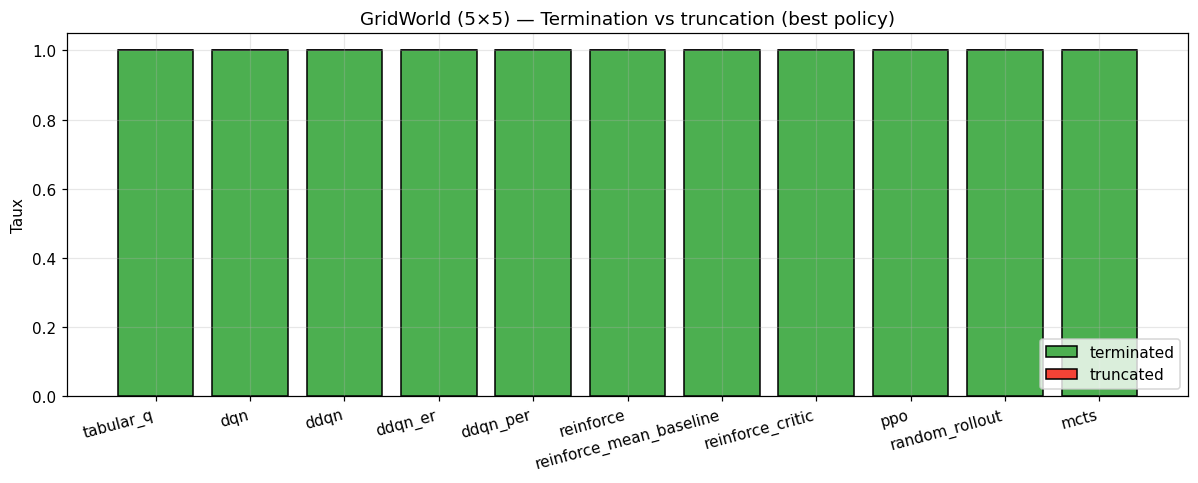

,termination_rate,truncation_rate,type
agent,,,
tabular_q,1.0000,0.0000,learning
dqn,1.0000,0.0000,learning
ddqn,1.0000,0.0000,learning
ddqn_er,1.0000,0.0000,learning
ddqn_per,1.0000,0.0000,learning
reinforce,1.0000,0.0000,learning
reinforce_mean_baseline,1.0000,0.0000,learning
reinforce_critic,1.0000,0.0000,learning
ppo,1.0000,0.0000,learning


In [12]:
rows = []
for a in [a for a in LEARNING_AGENTS if a in df_eval["agent"].unique()]:
    sub = df_eval[df_eval["agent"] == a].dropna(subset=["termination_rate", "mean_reward"])
    if sub.empty:
        continue
    best = sub.sort_values("mean_reward", ascending=False).iloc[0]
    rows.append({"agent": a, "termination_rate": best["termination_rate"],
                 "truncation_rate": 1.0 - best["termination_rate"], "type": "learning"})

for a in [a for a in PLANNING_AGENTS if not df_planning.empty and a in df_planning["agent"].unique()]:
    sub = df_planning[df_planning["agent"] == a].dropna(subset=["termination_rate", "mean_reward"])
    if sub.empty:
        continue
    best = sub.sort_values("mean_reward", ascending=False).iloc[0]
    rows.append({"agent": a, "termination_rate": best["termination_rate"],
                 "truncation_rate": 1.0 - best["termination_rate"], "type": "planning"})

if not rows:
    print("Pas de données termination.")
else:
    df_term = pd.DataFrame(rows).set_index("agent")
    df_term = df_term.reindex([a for a in ALL_AGENTS if a in df_term.index])
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.bar(df_term.index, df_term["termination_rate"], color="#4CAF50",
           label="terminated", edgecolor="black")
    ax.bar(df_term.index, df_term["truncation_rate"],
           bottom=df_term["termination_rate"], color="#F44336",
           label="truncated", edgecolor="black")
    ax.set_ylabel("Taux")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{ENV_TITLE} — Termination vs truncation (best policy)")
    ax.legend(loc="lower right")
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.show()
    display(df_term.round(3))


## 12. [PLANNING] MCTS et RandomRollout — sweep budget

Sweep produit par `scripts/evaluate_planning_agents.py`. Pour chaque budget, on évalue la performance et le coût en temps. La courbe gauche montre la qualité, la droite le coût (temps × budget).

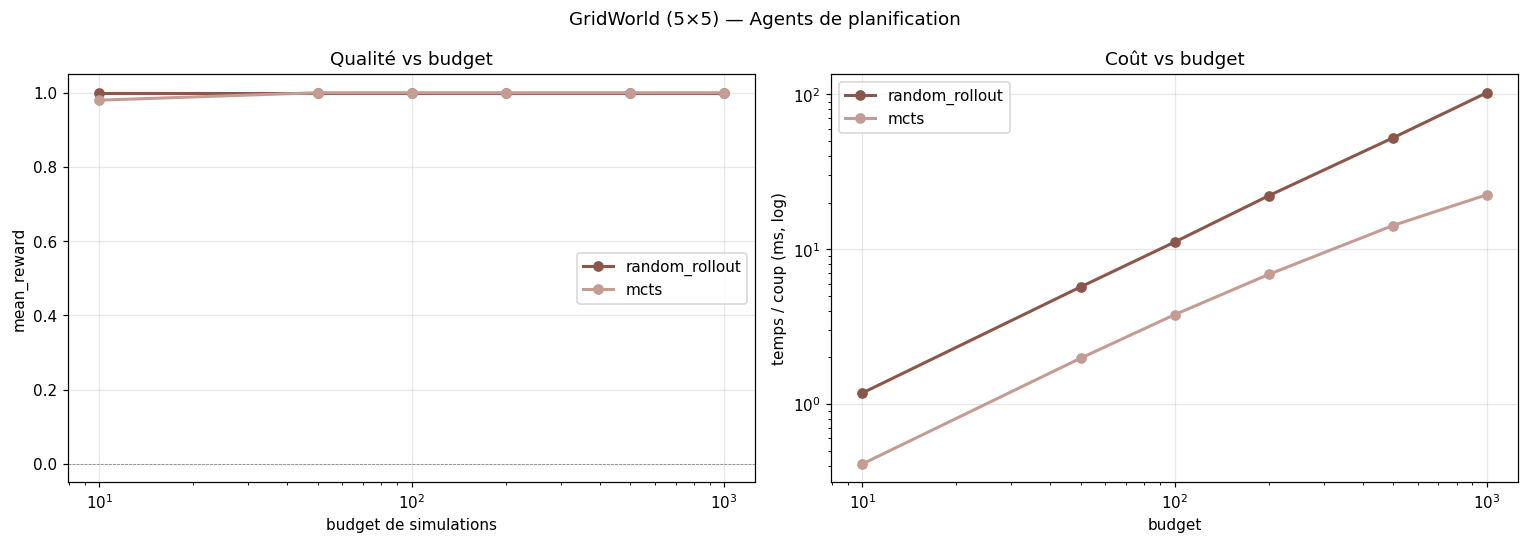

,agent,budget,mean_reward,win_rate,mean_steps,mean_action_time_ms
0,mcts,10,0.9800,NaN,44.4800,0.4100
1,mcts,50,1.0000,NaN,15.4400,1.9770
2,mcts,100,1.0000,NaN,13.1200,3.7750
3,mcts,200,1.0000,NaN,10.2000,6.8680
4,mcts,500,1.0000,NaN,8.8400,14.2250
5,mcts,1000,1.0000,NaN,8.2800,22.5010
6,random_rollout,10,1.0000,NaN,21.5600,1.1780
7,random_rollout,50,1.0000,NaN,12.2000,5.7080
8,random_rollout,100,1.0000,NaN,10.1000,11.1160
9,random_rollout,200,1.0000,NaN,8.9400,22.1490


In [13]:
if df_planning.empty:
    print("Pas de données planning. Lance :")
    print(f"  uv run scripts/evaluate_planning_agents.py configs_done/mcts/{ENV_NAME}.yaml")
    print(f"  uv run scripts/evaluate_planning_agents.py configs_done/random_rollout/{ENV_NAME}.yaml")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for a in [a for a in PLANNING_AGENTS if a in df_planning["agent"].unique()]:
        sub = df_planning[df_planning["agent"] == a].sort_values("budget")
        axes[0].plot(sub["budget"], sub["mean_reward"], marker="o",
                     label=a, color=agent_color(a), linewidth=2)
        axes[1].plot(sub["budget"], sub["mean_action_time_ms"], marker="o",
                     label=a, color=agent_color(a), linewidth=2)
    axes[0].set_xscale("log")
    axes[0].set_xlabel("budget de simulations")
    axes[0].set_ylabel("mean_reward")
    axes[0].set_title("Qualité vs budget")
    axes[0].axhline(0, color="gray", lw=0.5, ls="--")
    axes[0].legend()
    axes[1].set_xscale("log"); axes[1].set_yscale("log")
    axes[1].set_xlabel("budget"); axes[1].set_ylabel("temps / coup (ms, log)")
    axes[1].set_title("Coût vs budget")
    axes[1].legend()
    plt.suptitle(f"{ENV_TITLE} — Agents de planification")
    plt.tight_layout()
    plt.show()
    cols = ["agent", "budget", "mean_reward", "mean_steps", "mean_action_time_ms"]
    if "win_rate" in df_planning.columns:
        cols.insert(3, "win_rate")
    display(df_planning[cols].sort_values(["agent", "budget"]).reset_index(drop=True))


## 13. [PARETO] Reward × latence — toutes les méthodes

Chaque point = une (agent, configuration). On cherche le coin **haut-gauche** : reward élevé, temps faible. Les triangles = planning agents.

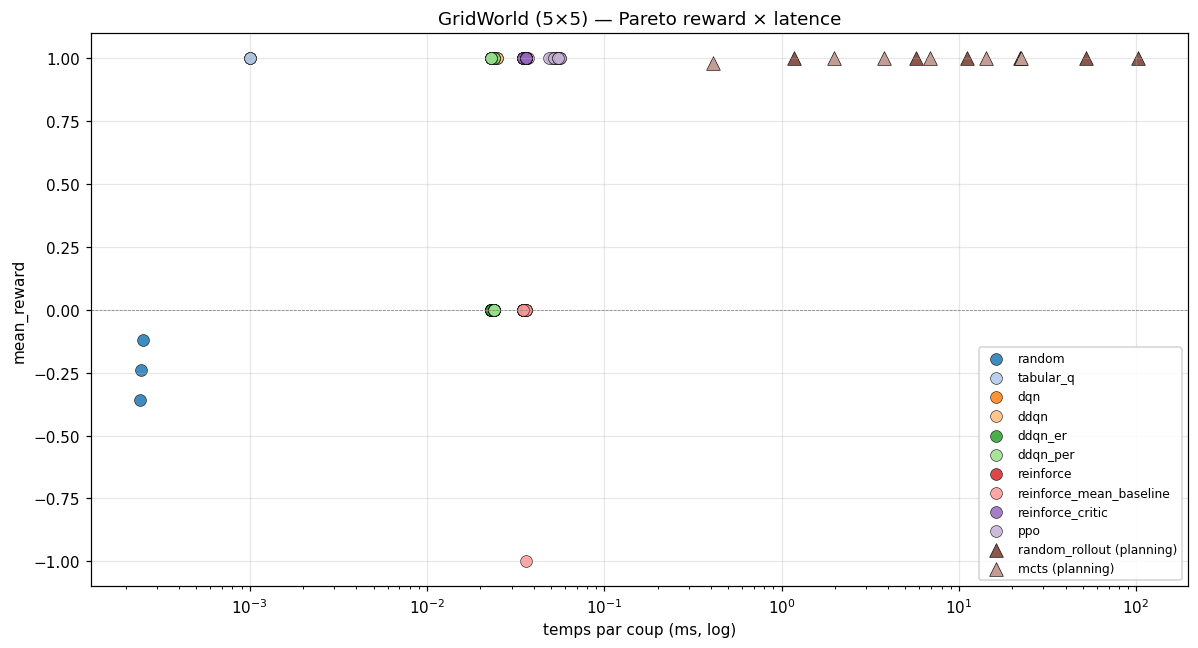

In [14]:
fig, ax = plt.subplots(figsize=(11, 6))

if not df_eval.empty:
    for a in [a for a in LEARNING_AGENTS if a in df_eval["agent"].unique()]:
        sub = df_eval[df_eval["agent"] == a].dropna(subset=["mean_reward", "mean_action_time_ms"])
        if sub.empty:
            continue
        ax.scatter(sub["mean_action_time_ms"], sub["mean_reward"],
                   s=60, color=agent_color(a), edgecolor="black", linewidth=0.4,
                   label=f"{a}", alpha=0.85)

if not df_planning.empty:
    for a in [a for a in PLANNING_AGENTS if a in df_planning["agent"].unique()]:
        sub = df_planning[df_planning["agent"] == a].dropna(subset=["mean_reward", "mean_action_time_ms"])
        if sub.empty:
            continue
        ax.scatter(sub["mean_action_time_ms"], sub["mean_reward"],
                   s=80, color=agent_color(a), marker="^", edgecolor="black",
                   linewidth=0.4, label=f"{a} (planning)")

ax.set_xscale("log")
ax.set_xlabel("temps par coup (ms, log)")
ax.set_ylabel("mean_reward")
ax.set_title(f"{ENV_TITLE} — Pareto reward × latence")
ax.axhline(0, color="gray", lw=0.5, ls="--")
ax.legend(loc="best", fontsize=8, framealpha=0.85)
plt.tight_layout()
plt.show()


## 14. Hyperparamètres

Snapshot tels qu'utilisés pendant l'entraînement (lus depuis `results/{env}/{agent}/{run}/config.yaml`).

In [15]:
hp_rows = []
for r in learning_runs + planning_runs:
    cfg = r["config"]
    flat = {"agent": r["agent"], "seed": cfg.get("seed", "")}
    for k, v in (cfg.get("agent_params") or {}).items():
        flat[f"ap.{k}"] = v
    if "training" in cfg:
        flat["num_episodes"] = cfg["training"].get("num_episodes", "")
    if "budgets" in cfg:
        flat["budgets"] = str(cfg["budgets"])
    hp_rows.append(flat)
hp = pd.DataFrame(hp_rows).set_index("agent")
hp


,seed,ap.batch_size,ap.buffer_capacity,ap.epsilon_decay_steps,ap.epsilon_end,ap.epsilon_start,ap.gamma,ap.hidden_layers,ap.lr,ap.target_update_freq,...,ap.gae_lambda,ap.max_grad_norm,ap.n_epochs,ap.value_coef,ap.critic_lr,ap.c_uct,ap.max_rollout_depth,ap.n_simulations,budgets,ap.n_rollouts_per_action
agent,,,,,,,,,,,,,,,,,,,,,
ddqn,123,64.0000,10000.0000,20000.0000,0.0100,1.0000,0.9900,"[64, 64]",0.0003,200.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ddqn,42,64.0000,10000.0000,20000.0000,0.0100,1.0000,0.9900,"[64, 64]",0.0003,200.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ddqn,42,64.0000,10000.0000,20000.0000,0.0100,1.0000,0.9900,"[64, 64]",0.0010,200.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ddqn_er,123,64.0000,10000.0000,20000.0000,0.0100,1.0000,0.9900,"[64, 64]",0.0003,200.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ddqn_er,42,64.0000,10000.0000,20000.0000,0.0100,1.0000,0.9900,"[64, 64]",0.0003,200.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ddqn_er,42,64.0000,10000.0000,20000.0000,0.0100,1.0000,0.9900,"[64, 64]",0.0010,200.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ddqn_per,123,64.0000,10000.0000,20000.0000,0.0100,1.0000,0.9900,"[64, 64]",0.0003,200.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ddqn_per,42,64.0000,10000.0000,20000.0000,0.0100,1.0000,0.9900,"[64, 64]",0.0003,200.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ddqn_per,42,64.0000,10000.0000,20000.0000,0.0100,1.0000,0.9900,"[64, 64]",0.0010,200.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 15. Synthèse — ranking final

Tableau trié par `mean_reward` (best run pour les apprenants, max budget pour les planning agents). En cas d'égalité, on départage par temps d'inférence faible.

In [16]:
rows = []
for a in [a for a in LEARNING_AGENTS if a in df_eval["agent"].unique()]:
    sub = df_eval[df_eval["agent"] == a].dropna(subset=["mean_reward"])
    if sub.empty:
        continue
    best = sub.sort_values(["mean_reward", "mean_steps"], ascending=[False, True]).iloc[0]
    rows.append({
        "method": a, "kind": "learning",
        "config": f"ckpt={int(best['checkpoint'])}",
        "mean_reward": best["mean_reward"],
        "mean_steps": best["mean_steps"],
        "mean_action_time_ms": best["mean_action_time_ms"],
        "termination_rate": best.get("termination_rate", float("nan")),
    })

if not df_planning.empty:
    for a in [a for a in PLANNING_AGENTS if a in df_planning["agent"].unique()]:
        sub = df_planning[df_planning["agent"] == a].dropna(subset=["mean_reward"])
        if sub.empty:
            continue
        best = sub.sort_values(["mean_reward", "budget"], ascending=[False, True]).iloc[0]
        rows.append({
            "method": a, "kind": "planning",
            "config": f"budget={int(best['budget'])}",
            "mean_reward": best["mean_reward"],
            "mean_steps": best["mean_steps"],
            "mean_action_time_ms": best["mean_action_time_ms"],
            "termination_rate": best.get("termination_rate", float("nan")),
        })

if not rows:
    print("Pas de données pour ranking.")
else:
    ranking = pd.DataFrame(rows).sort_values(
        ["mean_reward", "mean_action_time_ms"], ascending=[False, True]
    ).reset_index(drop=True)
    ranking.index = ranking.index + 1
    ranking.index.name = "rank"
    display(ranking.round(4))


,method,kind,config,mean_reward,mean_steps,mean_action_time_ms,termination_rate
rank,,,,,,,
1,tabular_q,learning,ckpt=1000,1.0000,8.0000,0.0010,1.0000
2,ddqn,learning,ckpt=10000,1.0000,8.0000,0.0230,1.0000
3,dqn,learning,ckpt=10000,1.0000,8.0000,0.0240,1.0000
4,ddqn_er,learning,ckpt=1000,1.0000,8.0000,0.0240,1.0000
5,ddqn_per,learning,ckpt=1000,1.0000,8.0000,0.0240,1.0000
6,reinforce,learning,ckpt=2000,1.0000,8.0000,0.0360,1.0000
7,reinforce_critic,learning,ckpt=500,1.0000,8.0000,0.0360,1.0000
8,reinforce_mean_baseline,learning,ckpt=1000,1.0000,8.0000,0.0370,1.0000
9,ppo,learning,ckpt=1000,1.0000,8.0000,0.0510,1.0000


## 16. Observations critiques

### Observations critiques — GridWorld

- L'optimum théorique est `mean_reward ≈ 1.0` avec ~ 8 steps minimum.
- Les value-based DQN/DDQN/DDQN+ER/DDQN+PER atteignent 1.0 si `epsilon_decay_steps` est suffisamment long pour bien explorer.
- `mcts` et `random_rollout` à budget ≥ 100 atteignent l'optimum sans entraînement (mais avec un coût élevé : ~ 50 ms/coup à budget 200).
- Risque de **truncation** si la politique tourne en rond (cas observé sur runs sous-entraînés ou avec lr trop grand → divergence).
- `ppo` est le seul qui n'a pas un comportement parfaitement stable sur GridWorld : il faut tuner `entropy_coef` et `lr` ensemble.
